# Two-State Two-Action Mean-Field Control Benchmark

Reference: Meunier, Pham & Reisinger, discrete-space benchmarks, Section "Two-State Two-Action Toy Problem" (`files/reference/discrete_benchmarks.tex`).

**Model.** State space $\mathcal X=\{0,1\}$, action space $\mathcal A=\{\mathrm{ST},\mathrm{MV}\}$. $\mathrm{ST}$ leaves the state unchanged; $\mathrm{MV}$ attempts to switch to the other state and succeeds with probability $\lambda_x$ ($\lambda_0=0.5$, $\lambda_1=0.8$). The transition kernel does not depend on the population law; the mean-field interaction enters only through the reward

$$r(x,\mu) = \mathbf 1_{\{x=1\}} - \mu(1)^2 - \kappa\,|\mu(1)-(1-p)|,\qquad g=r,$$

with $\kappa=10$, $p=0.6$, target law $\bar\mu=(p,1-p)=(0.6,0.4)$.

**Policy.** A stationary Bernoulli-logit policy $\pi^\theta(\mathrm{MV}\mid x)=\mathrm{sigmoid}(\theta_x)$, shared across the estimators compared below (`mfc.environments.twostate.TwoState.policy_probs`).

**Algorithms.** `simplex` (`mfc.algorithms.simplex`, swept across the perturbation scale $\lambda$), `mfreinforce` (logit-perturbed, fixed $\epsilon$), and `reinforce` (the missing-mean-field-term ablation).

**Known optimum.** For these parameters the optimal stationary policy is known in closed form ($\pi^*(\mathrm{ST}\mid 0)=0.2$, $\pi^*(\mathrm{ST}\mid 1)=0.25$), which is what lets every diagnostic below compare the learned policy against ground truth rather than only against itself.

**This notebook shows `main`-tier results automatically whenever they're available.** `configs/twostate.py`'s `MAIN` doesn't sweep the full `budget_modes x flows x horizons` cartesian product: only 5 explicit `(budget_mode, flow, T)` groups (`MAIN.groups`, see its module docstring), comparing **equal_parameters vs equal_budget** (exact flow, $T=2$), **exact vs particle** flow (equal_budget, $T=2$), and horizon scaling $T\in\{2,5,10\}$ (equal_budget, particle), 5 seeds each. Sections that need axes `mid` doesn't cover (multiple seeds, multiple groups) check for `runs/twostate/main/` and print a note instead of failing if it isn't there yet; run `scripts/train_all.sh <workers> --env twostate --alg <alg> --config main` (once per algorithm) to populate them.

In [1]:
import sys
import time
from pathlib import Path

_notebook_start = time.perf_counter()

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
for path in (SRC, ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import torch
import pandas as pd

torch.set_default_dtype(torch.float64)
torch.set_default_device("cuda" if torch.cuda.is_available() else "cpu")

from configs.twostate import MAIN, MID
from mfc.environments.twostate import TwoState, TwoStateConfig
from mfc.algorithms import simplex
from mfc.plotting import diagnostics as viz
from scripts.train import run_all
from scripts.test import (
    constant_policy_fn,
    exact_gradient,
    exact_sensitivity_flow,
    generalization_eval,
    gradient_diagnostics,
    group_by,
    load_runs,
    logit_perturbation_coverage,
    objective_gap,
    oracle_gradient_estimate,
    perturbation_coverage,
    policy_error,
    population_tracking_error,
    rollout,
    sensitivity_estimation_error,
    state_distribution,
    state_marginal_stability,
    theta_diagnostics,
)

DEFAULT_GROUP = ("equal_parameters", "exact", 2)  # mid's own (only) group; also main.groups[0]

## Configuration and budget

Auto-detects whether `runs/twostate/main/` has any saved runs and uses `main` if so (5 seeds, the full 5-group sweep), otherwise `mid` (1 seed, the `equal_parameters`/`exact`/$T=2$ group only). Every section below works at either tier; the main-only sections (budget/flow comparison, seed variance, horizon scaling) note when they need `main` data that isn't there yet.

In [2]:
main_dir = ROOT / "runs" / "twostate" / "main"
tier = "main" if list(main_dir.glob("*_seed*.pt")) else "mid"
cfg = MAIN if tier == "main" else MID

print(f"tier: {tier}")
print(f"algorithms:    {cfg.algorithms}")
print(f"lambdas:       {cfg.lambdas}  (simplex perturbation scale)")
print(f"epsilon:       {cfg.epsilon}  (logit perturbation scale, fixed -- not swept like lambda)")
print(f"seeds:         {cfg.seeds}")
print(f"B={cfg.B}, n_aux={cfg.n_aux}, sigma={cfg.sigma}, lr={cfg.lr}, n_train={cfg.n_train}")
print(f"mu0(1) ~ U([{cfg.mu0_low}, {cfg.mu0_high}]) during training; validation mu0={cfg.mu0_val}")
if tier == "main":
    print(f"groups (budget_mode, flow, T): {cfg.groups}")
else:
    print(f"budget_modes={cfg.budget_modes}, flows={cfg.flows}, horizons={cfg.horizons}")
    print("\n(no runs/twostate/main/ data yet, showing mid-tier results; run scripts/train_all.sh "
          "<workers> --env twostate --alg <alg> --config main, once per algorithm, to populate the "
          "main-only sections below)")

tier: main
algorithms:    ('simplex', 'mfreinforce', 'reinforce')
lambdas:       (0.05, 0.1, 0.2, 0.4, 0.8)  (simplex perturbation scale)
epsilon:       0.2  (logit perturbation scale, fixed -- not swept like lambda)
seeds:         (0, 1, 2, 3, 4)
B=200, n_aux=10, sigma=1.0, lr=0.001, n_train=10000
mu0(1) ~ U([0.1, 0.9]) during training; validation mu0=(0.2, 0.8)
groups (budget_mode, flow, T): (('equal_parameters', 'exact', 2), ('equal_budget', 'exact', 2), ('equal_budget', 'particle', 2), ('equal_budget', 'particle', 5), ('equal_budget', 'particle', 10))


## Train (or load cached results)

At `mid`, trains first if nothing is cached yet (cheap: ~7 runs). At `main`, only loads what's already there: training the full 5-group sweep is expensive and belongs in `scripts/train_all.sh`, not an inline notebook cell. If the loaded runs turn out to be float32 (`scripts/train.py --dtype float32`), `env` and the notebook's default dtype are switched to match: every tensor built from here on (including `mu0_val`, `optimal_theta`, and the generalization scenarios below) needs to interoperate with the loaded `theta_final`s, and PyTorch doesn't silently mix float32/float64 in operations like `einsum`.

In [3]:
env = TwoState()
runs_dir = ROOT / "runs" / "twostate" / tier

runs = []
for alg in cfg.algorithms:
    if tier == "mid" and not list(runs_dir.glob(f"{alg}_*_seed*.pt")):
        run_all("twostate", alg, "mid")
    runs += load_runs("twostate", alg, tier)

if runs and runs[0]["theta_final"].dtype != env.dtype:
    run_dtype = runs[0]["theta_final"].dtype
    print(f"note: loaded runs are {run_dtype}, switching env and the notebook's default dtype to match (was {env.dtype})")
    torch.set_default_dtype(run_dtype)
    env = TwoState(dtype=run_dtype)

total_train_seconds = sum(r["elapsed_seconds"] for r in runs)
print(f"{len(runs)} runs loaded ({tier}); total training compute time: {total_train_seconds:.1f}s ({total_train_seconds / 60:.1f} min)")

note: loaded runs are torch.float32, switching env and the notebook's default dtype to match (was torch.float64)
175 runs loaded (main); total training compute time: 81563.6s (1359.4 min)


## Ground truth

The closed-form optimal policy and its equivalent $\theta^*$ under this notebook's Bernoulli-logit parametrization (`TwoState.optimal_policy`, `TwoState.optimal_theta`), plus the exact objective at $\theta^*$: the reference line every plot below compares against.

In [4]:
mu0_val = torch.tensor(cfg.mu0_val)
optimal_theta = env.optimal_theta()
optimal_J = simplex.exact_objective(env, env.policy_probs, optimal_theta, mu0_val, DEFAULT_GROUP[2]).item()

print("optimal policy pi*(a|x):")
print(env.optimal_policy())
print(f"\noptimal theta*: {optimal_theta.tolist()}")
print(f"J(theta*; mu0_val={cfg.mu0_val}) = {optimal_J:.4f}")

optimal policy pi*(a|x):
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')

optimal theta*: [1.3862944841384888, 1.0986123085021973]
J(theta*; mu0_val=(0.2, 0.8)) = -3.3600


## Default group

Sections below that only need one `(budget_mode, flow, T)` group use `DEFAULT_GROUP = (equal_parameters, exact, T=2)`: `mid`'s own (only) group, also the first of `main`'s 5. `by_lambda` picks seed 0 as a representative $\theta$ per $\lambda$ (used only where a single sampled trajectory is needed); `by_lambda_all_seeds` keeps every seed for the aggregate diagnostics, which cover every $\lambda$ throughout this notebook, not just one.

In [5]:
group_runs = [r for r in runs if (r["budget_mode"], r["flow"], r["T"]) == DEFAULT_GROUP]
simplex_group_runs = [r for r in group_runs if r["alg"] == "simplex"]
mfreinforce_group_runs = [r for r in group_runs if r["alg"] == "mfreinforce"]
reinforce_group_runs = [r for r in group_runs if r["alg"] == "reinforce"]

by_lambda_all_seeds = {lam: grp for (lam,), grp in group_by(simplex_group_runs, "lam").items()}
by_lambda = {lam: next((r for r in grp if r["seed"] == 0), grp[0]) for lam, grp in by_lambda_all_seeds.items()}
theta_02 = by_lambda[0.2]["theta_final"]

print(f"default group (budget_mode, flow, T) = {DEFAULT_GROUP}: {len(simplex_group_runs)} simplex runs "
      f"across {len(by_lambda)} lambda values, {len(mfreinforce_group_runs)} mfreinforce run(s), {len(reinforce_group_runs)} reinforce run(s)")

default group (budget_mode, flow, T) = ('equal_parameters', 'exact', 2): 25 simplex runs across 5 lambda values, 5 mfreinforce run(s), 5 reinforce run(s)


## Evolution of the validation reward

The exact validation objective $J(\theta_m;\mu_0^{val})$ every 10 training iterations, one line per simplex $\lambda$ plus mfreinforce and reinforce (each contributing a single line, since neither sweeps a perturbation scale), against the optimal value $J(\theta^*)$. At `main`, each line is the mean $\pm$ 1 std across 5 seeds (`plot_validation_curve` averages automatically whenever more than one seed is passed in).

Text(0.5, 1.0, 'Validation objective during training (main tier)')

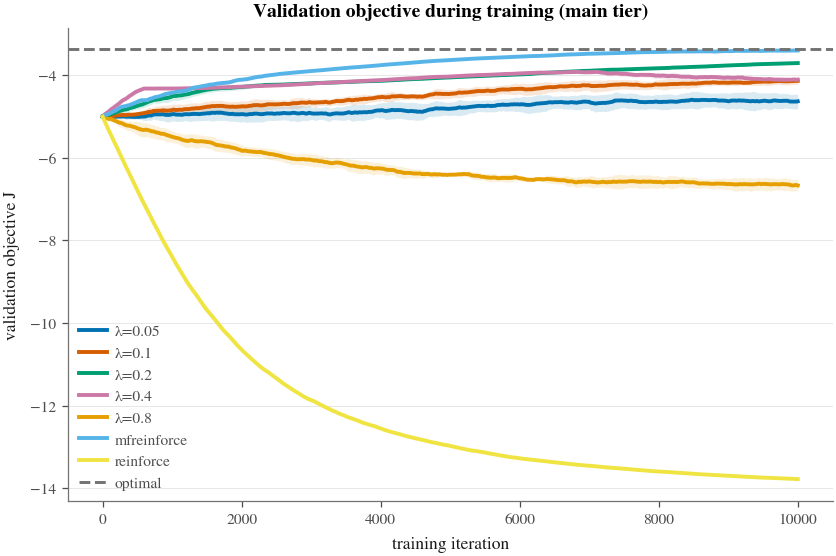

In [6]:
fig, ax = viz.plot_validation_curve(group_runs, optimal_J=optimal_J)
ax.set_title(f"Validation objective during training ({tier} tier)")

## State distribution over time

The learned policy's population flow $\mu_t^\theta(1)$ from $\mu_0^{val}$ ($t=0,\ldots,2$, since $T=2$), for every $\lambda$ (seed 0), against the flow under the optimal policy. $\mu_t^\theta(0)=1-\mu_t^\theta(1)$ throughout, so this one column determines the whole law. The graph below shows $\lambda=0.2$ specifically (learned, solid; optimal, dashed; target law $\bar\mu$, dotted); the table gives every $\lambda$.

target law bar_mu(1) = 0.4000


,mu_0(1),mu_1(1),mu_2(1)
theta,,,
lambda=0.05,0.8,0.496285,0.405798
lambda=0.1,0.8,0.468989,0.393024
lambda=0.2,0.8,0.410397,0.373656
lambda=0.4,0.8,0.382274,0.345830
lambda=0.8,0.8,0.595362,0.526266
optimal,0.8,0.400000,0.400000


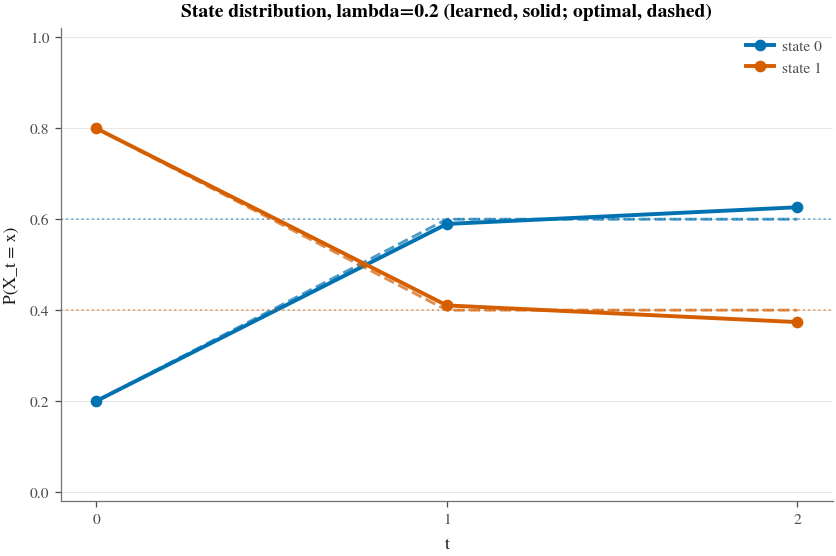

In [7]:
learned_flow = state_distribution(env, env.policy_probs, theta_02, mu0_val, DEFAULT_GROUP[2])
optimal_flow = state_distribution(env, constant_policy_fn(env.optimal_policy()), optimal_theta, mu0_val, DEFAULT_GROUP[2])

fig, ax = viz.plot_state_distribution(learned_flow, target_law=env.target_law, optimal_flow=optimal_flow)
ax.set_title("State distribution, lambda=0.2 (learned, solid; optimal, dashed)")

rows = []
for lam in sorted(by_lambda):
    flow = state_distribution(env, env.policy_probs, by_lambda[lam]["theta_final"], mu0_val, DEFAULT_GROUP[2])
    rows.append({"theta": f"lambda={lam}", **{f"mu_{t}(1)": flow[t, 1].item() for t in range(flow.shape[0])}})
rows.append({"theta": "optimal", **{f"mu_{t}(1)": optimal_flow[t, 1].item() for t in range(optimal_flow.shape[0])}})

print(f"target law bar_mu(1) = {env.target_law[1].item():.4f}")
pd.DataFrame(rows).set_index("theta")

## $J^\lambda(\hat\theta_\lambda)$ vs $J(\hat\theta_\lambda)$, policy error, and population-tracking error

Three diagnostics, all evaluated at $\hat\theta_\lambda$: **each $\lambda$'s own seed-0 learned parameter**, not the optimal $\theta^*$ and not a single shared $\theta$:
- $J^\lambda(\hat\theta_\lambda)$ (Monte Carlo, perturbed) vs $J(\hat\theta_\lambda)$ (exact): the perturbation's effect on the objective, evaluated at the parameter that perturbation itself produced.
- Policy error $|\pi^{\hat\theta_\lambda}(\cdot\mid x)-\pi^*(\cdot\mid x)|$ per state (the reference's $\mathcal E_0,\mathcal E_1$).
- Population-tracking error $\frac1T\sum_t d_{TV}(\mu_t^{\hat\theta_\lambda},\bar\mu)$ (the reference's $\mathcal E_\text{flow}$).

$J^\lambda$ and the plug-in gradient are only defined for the simplex perturbation (`objective_gap` calls `simplex.estimate_objective` directly), so mfreinforce and reinforce have no $J^\lambda$ column; their own exact $J(\hat\theta)$ (seed 0) is included in the table below for comparison.

,J(theta_hat),J^lambda(theta_hat) (MC),E_flow
theta,,,
lambda=0.05,-4.369720,-4.256376,0.051042
lambda=0.1,-4.112047,-3.919593,0.037982
lambda=0.2,-3.731398,-3.473134,0.018370
lambda=0.4,-4.096588,-3.550839,0.035948
lambda=0.8,-6.566061,-4.196627,0.160814
mfreinforce,-3.410367,NaN,0.002499
reinforce,-13.783694,NaN,0.505682


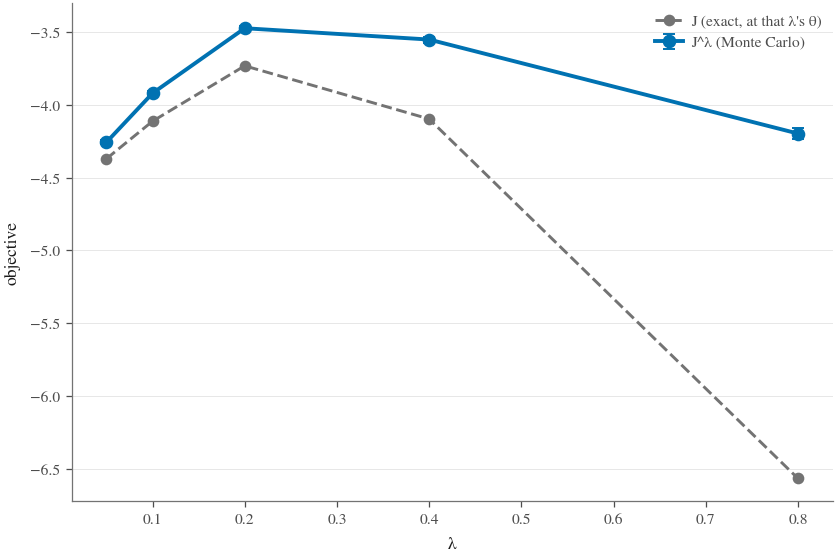

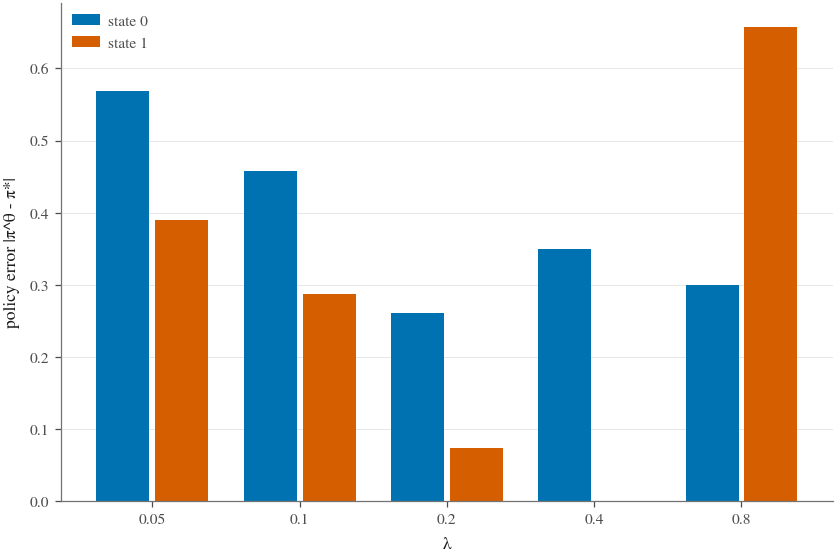

In [8]:
gaps, errors, tracking = {}, {}, {}
for lam, r in by_lambda.items():
    theta = r["theta_final"]
    gaps[lam] = objective_gap(env, env.policy_probs, theta, mu0_val, DEFAULT_GROUP[2], lam=lam, sigma=cfg.sigma, n_samples=5000)
    errors[lam] = policy_error(env, env.policy_probs, theta)
    tracking[lam] = population_tracking_error(env, env.policy_probs, theta, mu0_val, DEFAULT_GROUP[2]).item()

fig, ax = viz.plot_objective_gap(gaps)
fig, ax = viz.plot_policy_error(errors)

rows = []
for lam in sorted(tracking):
    rows.append({
        "theta": f"lambda={lam}",
        "J(theta_hat)": gaps[lam]["J"].item(),
        "J^lambda(theta_hat) (MC)": gaps[lam]["J_lambda_mean"].item(),
        "E_flow": tracking[lam],
    })
for alg_name, group in [("mfreinforce", mfreinforce_group_runs), ("reinforce", reinforce_group_runs)]:
    r0 = next((r for r in group if r["seed"] == 0), group[0])
    theta = r0["theta_final"]
    rows.append({
        "theta": alg_name,
        "J(theta_hat)": simplex.exact_objective(env, env.policy_probs, theta, mu0_val, DEFAULT_GROUP[2]).item(),
        "J^lambda(theta_hat) (MC)": None,
        "E_flow": population_tracking_error(env, env.policy_probs, theta, mu0_val, DEFAULT_GROUP[2]).item(),
    })
pd.DataFrame(rows).set_index("theta")

## Gradient bias and variance

The simplex plug-in gradient estimator (`mfc.algorithms.simplex.gradient_estimate`) is

$$\hat g_{B,n,\lambda,\eta}(\theta) = \frac1B\sum_{b=1}^B\sum_{t=0}^{T}\Big[\mathbb 1_{\{t<T\}}L_t^{(b)} + Q_t^{(b)}\Big]\,G_t^{(b)},$$

with $L_t=\nabla_\theta\log\pi_t^\theta(a_t\mid x_t,M_t)$ the direct policy score, $Q_t=-\frac{1-\lambda}{\lambda}H(q_t)^\top\hat D_t$ the population-sensitivity correction ($H$ the simplex perturbation's own score, $\hat D_t\approx\nabla_\theta\mu_t^\theta$ from a shared auxiliary batch), and $G_t$ the return-to-go. This section compares 30 independent draws of $\hat g(\theta)$ against the exact gradient $\nabla_\theta J(\theta)$ (autograd through the differentiable population flow), at each $\lambda$'s learned $\hat\theta_\lambda$ (seed 0):

$$\text{bias}=\mathbb E[\hat g(\theta)]-\nabla_\theta J(\theta), \qquad \text{std}=\sqrt{\mathrm{Var}(\hat g(\theta))}.$$

Only simplex has this plug-in estimator; mfreinforce's own (logit-perturbed) gradient estimator and reinforce's (no perturbation) aren't directly comparable to it component-by-component, so this section stays simplex-only.

In [9]:
gd_by_lambda = {
    lam: gradient_diagnostics(
        env, env.policy_probs, r["theta_final"], mu0_val, DEFAULT_GROUP[2],
        lam=lam, n_aux=cfg.n_aux, B=cfg.B, sigma=cfg.sigma, reps=30,
    )
    for lam, r in by_lambda.items()
}
rows = []
for lam in sorted(gd_by_lambda):
    d = gd_by_lambda[lam]
    rows.append({
        "lambda": lam,
        "bias_theta0": d["bias"][0].item(), "std_theta0": d["std"][0].item(),
        "bias_theta1": d["bias"][1].item(), "std_theta1": d["std"][1].item(),
        "||bias||": d["bias"].norm().item(), "||std||": d["std"].norm().item(),
    })
pd.DataFrame(rows).set_index("lambda")

,bias_theta0,std_theta0,bias_theta1,std_theta1,||bias||,||std||
lambda,,,,,,
0.05,-0.261126,14.482282,-12.813723,41.733028,12.816383,44.174450
0.10,-0.446005,3.938850,1.583991,6.032670,1.645585,7.204697
0.20,-0.518906,0.417776,-0.342457,0.733664,0.621724,0.844275
0.40,-0.883728,0.753416,1.658551,1.332669,1.879299,1.530896
0.80,0.763369,0.246504,-3.260985,0.268136,3.349142,0.364227


## Budget mode and flow comparison (main tier)

The actual point of `main`'s 5-group sweep: compare **equal_parameters vs equal_budget** (exact flow, $T=2$), and **exact vs particle** flow (equal_budget, $T=2$), for every algorithm; simplex at $\lambda=0.2$. Final validation $J$, mean $\pm$ std across `main`'s 5 seeds; `optimal J` printed above the table for reference. Requires `runs/twostate/main/`.

In [10]:
if tier != "main":
    print("main-tier data not available yet -- run scripts/train_all.sh to populate this section")
else:
    rows = []
    for budget_mode, flow, T in cfg.groups:
        row = {"budget_mode": budget_mode, "flow": flow, "T": T}
        for alg in cfg.algorithms:
            sel = [r for r in runs if r["alg"] == alg and r["budget_mode"] == budget_mode and r["flow"] == flow and r["T"] == T and (alg != "simplex" or r["lam"] == 0.2)]
            vals = torch.tensor([r["validation_J"][-1].item() for r in sel])
            row[alg] = f"{vals.mean().item():.4f} +- {vals.std().item():.4f}" if len(vals) > 1 else f"{vals.item():.4f}"
        rows.append(row)

    print(f"optimal J = {optimal_J:.4f}  (simplex column is at lambda=0.2)")
    display(pd.DataFrame(rows).set_index(["budget_mode", "flow", "T"]))

optimal J = -3.3600  (simplex column is at lambda=0.2)


simplex        mfreinforce  \
budget_mode      flow     T                                          
equal_parameters exact    2   -3.7046 +- 0.0236  -3.4002 +- 0.0112   
equal_budget     exact    2   -3.6921 +- 0.0204  -3.4002 +- 0.0112   
                 particle 2   -3.9213 +- 0.0442  -3.5704 +- 0.0282   
                          5   -4.8639 +- 0.2352  -4.6528 +- 0.2420   
                          10  -4.2583 +- 0.4318  -4.5500 +- 0.8828   

                                       reinforce  
budget_mode      flow     T                       
equal_parameters exact    2   -13.7806 +- 0.0108  
equal_budget     exact    2   -14.0839 +- 0.0026  
                 particle 2   -14.0842 +- 0.0025  
                          5   -31.4557 +- 0.0063  
                          10  -61.1436 +- 0.0032

## Theta bias and variance across seeds

`mid` trains a single seed per $\lambda$, so seed-to-seed variance isn't visible from it. This uses `main`'s real 5 seeds at `DEFAULT_GROUP`. Dashed lines are $\theta^*$ (one per component, labeled "(optimal)" in the legend).

||theta*|| = 1.769; ||theta_mean - theta*|| per lambda:
  lambda=0.05  1.592
  lambda=0.1   1.295
  lambda=0.2   0.661
  lambda=0.4   0.840
  lambda=0.8   1.671


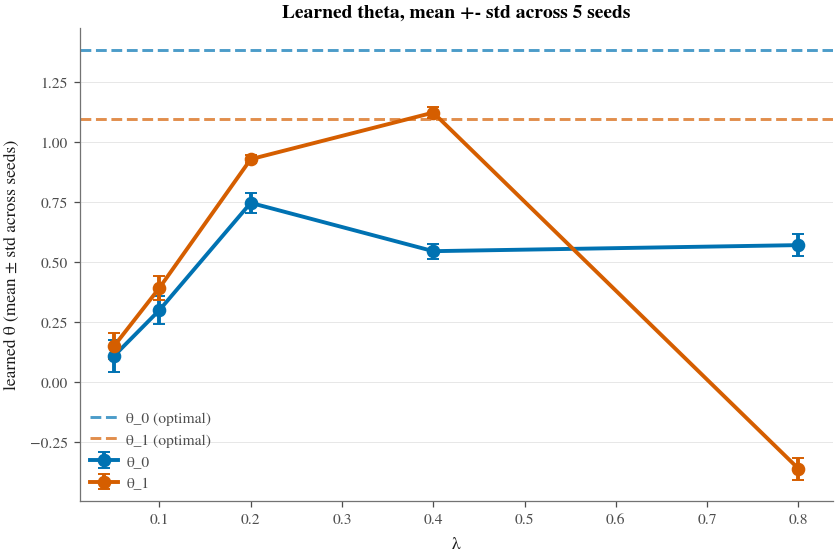

In [11]:
if tier != "main":
    print("main-tier data not available yet (mid only has 1 seed per lambda) -- run scripts/train_all.sh to populate this section")
else:
    theta_by_lambda = {lam: theta_diagnostics(torch.stack([r["theta_final"] for r in grp]), optimal_theta) for lam, grp in by_lambda_all_seeds.items()}
    fig, ax = viz.plot_theta_diagnostics(theta_by_lambda, optimal_theta=optimal_theta)
    ax.set_title(f"Learned theta, mean +- std across {len(cfg.seeds)} seeds")

    print(f"||theta*|| = {optimal_theta.norm().item():.3f}; ||theta_mean - theta*|| per lambda:")
    for lam in sorted(theta_by_lambda):
        print(f"  lambda={lam:<5} {(theta_by_lambda[lam]['mean'] - optimal_theta).norm().item():.3f}")

**Why does the learned theta differ from $\theta^*$ (dashed lines)?** Looking at the plot itself: each component of $\hat\theta_\lambda$ *rises* with $\lambda$ up to $\lambda\approx0.2$-$0.4$, then drops sharply at $\lambda=0.8$, an **inverted U** (a hump), not a monotone curve. Its *distance* to $\theta^*$ is the opposite shape, a **U**: largest at the smallest and largest $\lambda$, smallest around $\lambda=0.2$. Two effects, pulling in opposite directions, produce this:

1. **Estimator variance blows up as $\lambda\to0$.** The population-sensitivity term $Q_t=-\frac{1-\lambda}{\lambda}H(q_t)^\top\hat D_t$ carries an explicit $1/\lambda$ factor: a smaller perturbation is less biased in principle, but makes the gradient dramatically noisier in practice, so the *same fixed training budget* converges worse, not better, at small $\lambda$.
2. **Perturbation bias grows with $\lambda$.** The theorem's own $d_{TV}(M^\lambda,\mu)\le\lambda$ bound means larger $\lambda$ trains against an objective that increasingly diverges from the true, unperturbed $J$.

These trade off: $\lambda=0.2$ typically lands closest to $\theta^*$ (moderate variance, moderate bias), while both very small and very large $\lambda$ end up farther away. $\theta^*$ itself is also the fixed point of a *stationary* policy (`TwoState.optimal_policy`), while training only unrolls $T=2$ steps from a freshly resampled $\mu_0$ every iteration; part of the residual gap even at the best $\lambda$ reflects this genuinely different training objective, not estimator error alone.

## Simplex-perturbation coverage: $d_{TV}(M^\lambda,\mu)\le\lambda$

The perturbation theorem guarantees $d_{TV}(M_t^{\lambda,\theta},\mu_t^\theta)\le\lambda$ *almost surely* for the simplex perturbation. Checked here by direct sampling at a few representative population laws: every single draw must satisfy the bound, not just the average.

In [12]:
coverage = perturbation_coverage(torch.stack([mu0_val, env.target_law, torch.tensor([0.5, 0.5])]), lam=0.2, sigma=cfg.sigma, n_samples=5000)
for r in coverage:
    assert r["within_bound"], "the perturbation theorem's bound should never be violated"
pd.DataFrame([{"mu": mu_label, "mean_dTV": r["mean_dTV"].item(), "max_dTV": r["max_dTV"].item(), "bound (lambda)": 0.2, "within_bound": r["within_bound"]}
              for mu_label, r in zip(["mu0_val", "target_law", "uniform"], coverage)]).set_index("mu")

,mean_dTV,max_dTV,bound (lambda),within_bound
mu,,,,
mu0_val,0.061897,0.154448,0.2,True
target_law,0.038333,0.112645,0.2,True
uniform,0.034909,0.095230,0.2,True


mfreinforce's logit perturbation satisfies a *different*, weaker bound: only in expectation, $\mathbb E[d_{TV}(\mu,\mu_\varepsilon)]\le\varepsilon/2$ (`files/Discrete RL - Meunier, Pham, Reisinger.md`, Lemma 2.2, via Pinsker's inequality against the perturbation's KL divergence). Individual draws can and do exceed $\varepsilon/2$; `logit_perturbation_coverage` (`scripts/test.py`) checks the *sampled mean* against it, not every draw.

In [13]:
logit_coverage = logit_perturbation_coverage(torch.stack([mu0_val, env.target_law, torch.tensor([0.5, 0.5])]), epsilon=cfg.epsilon, n_samples=5000)
for r in logit_coverage:
    assert r["within_bound"], "Lemma 2.2's expected-value bound should hold at this sample size"
pd.DataFrame([{"mu": mu_label, "mean_dTV": r["mean_dTV"].item(), "max_dTV": r["max_dTV"].item(), "bound (epsilon/2)": cfg.epsilon / 2, "within_bound (mean)": r["within_bound"]}
              for mu_label, r in zip(["mu0_val", "target_law", "uniform"], logit_coverage)]).set_index("mu")

,mean_dTV,max_dTV,bound (epsilon/2),within_bound (mean)
mu,,,,
mu0_val,0.035820,0.208147,0.1,True
target_law,0.054599,0.275804,0.1,True
uniform,0.056248,0.256569,0.1,True


## Learned vs optimal trajectories

One sampled state trajectory for every $\lambda$ (seed 0) and one under the optimal policy, all starting from the *same* sampled initial state (drawn once from $\mu_0^{val}$, shared across every rollout) so the comparison is fair; independent generators are used for everything *after* $t=0$ (see the code comment for why that still matters).

In [14]:
# X_0 is sampled once and shared between every rollout below (as a one-hot
# mu0), so all trajectories start from the same state -- otherwise each
# independently draws X_0 ~ mu0_val=(0.2,0.8), and independent 80%-biased
# coin flips land on different outcomes often enough to be visually
# confusing. Independent generators are still used for the randomness
# *after* t=0: torch.multinomial's default generator produces markedly
# anti-correlated draws across back-to-back single-sample calls sharing one
# RNG stream (verified separately), which made sequentially-sampled
# trajectories look like near-exact opposites regardless of the policies.
# torch.Generator() does not follow torch.set_default_device, so it must be
# constructed explicitly on env.device to match the tensors it's used with.
x0 = torch.multinomial(mu0_val, 1, generator=torch.Generator(device=env.device).manual_seed(42)).squeeze(-1)
mu0_shared = torch.nn.functional.one_hot(x0, env.n_states).to(env.dtype)
print(f"shared initial state x0={x0.item()} (drawn from mu0_val={cfg.mu0_val})")

trajectories = {}
for lam in sorted(by_lambda):
    gen = torch.Generator(device=env.device).manual_seed(0)
    trajectories[f"lambda={lam}"] = rollout(env, env.policy_probs, by_lambda[lam]["theta_final"], mu0_shared, T=6, generator=gen)
trajectories["optimal"] = rollout(env, constant_policy_fn(env.optimal_policy()), optimal_theta, mu0_shared, T=6, generator=torch.Generator(device=env.device).manual_seed(1))

pd.DataFrame({name: traj.tolist() for name, traj in trajectories.items()}).rename_axis("t")

shared initial state x0=0 (drawn from mu0_val=(0.2, 0.8))


,lambda=0.05,lambda=0.1,lambda=0.2,lambda=0.4,lambda=0.8,optimal
t,,,,,,
0,0,0,0,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,0,1
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,0,0,0,0,0,1
6,0,0,0,0,0,0


## Generalization without retraining

Evaluating every $\lambda$'s learned $\hat\theta_\lambda$ (seed 0) exactly (no retraining) under different initial laws, a longer horizon, a stronger interaction penalty $\kappa$, and misspecified transition rates $\lambda_0,\lambda_1$. "reference J (optimal)" recomputes the *scenario's own* optimal policy and value (via `TwoState.optimal_theta`, which is a closed-form function of the config), not the baseline $\theta^*$, for every scenario that changes `env`, `mu0`, or `T`.

In [15]:
scenarios = [
    {"name": "baseline (mu0_val)"},
    {"name": "mu0=(0.5,0.5)", "mu0": torch.tensor([0.5, 0.5])},
    {"name": "mu0=(0.9,0.1)", "mu0": torch.tensor([0.9, 0.1])},
    {"name": "T=5", "T": 5},
    {"name": "kappa=20 (2x interaction)", "env": TwoState(TwoStateConfig(kappa=20.0), dtype=env.dtype, device=env.device)},
    {"name": "lambda0,1 shifted (misspecified)", "env": TwoState(TwoStateConfig(lambda0=0.4, lambda1=0.9), dtype=env.dtype, device=env.device)},
]

rows = {sc["name"]: {"scenario": sc["name"]} for sc in scenarios}
for sc in scenarios:
    sc_env = sc.get("env", env)
    sc_mu0 = sc.get("mu0", mu0_val)
    sc_T = sc.get("T", DEFAULT_GROUP[2])
    sc_optimal_theta = sc_env.optimal_theta()
    rows[sc["name"]]["reference J (optimal)"] = simplex.exact_objective(sc_env, sc_env.policy_probs, sc_optimal_theta, sc_mu0, sc_T).item()

for lam in sorted(by_lambda):
    gen_results = generalization_eval(env, env.policy_probs, by_lambda[lam]["theta_final"], mu0_val, DEFAULT_GROUP[2], scenarios)
    for res in gen_results:
        rows[res["name"]][f"lambda={lam}"] = res["J"].item()

pd.DataFrame(list(rows.values())).set_index("scenario")

,reference J (optimal),lambda=0.05,lambda=0.1,lambda=0.2,lambda=0.4,lambda=0.8
scenario,,,,,,
baseline (mu0_val),-3.360000,-4.369720,-4.112047,-3.731398,-4.096588,-6.566061
"mu0=(0.5,0.5)",-0.270001,-0.550628,-0.504212,-0.749598,-1.298709,-2.111418
"mu0=(0.9,0.1)",-2.430000,-4.165549,-3.822391,-3.333627,-3.850352,-3.307280
T=5,-2.640001,-4.487799,-4.232193,-3.933222,-5.147319,-8.720098
kappa=20 (2x interaction),-7.360001,-9.390552,-8.871688,-8.098804,-8.815548,-13.782337
"lambda0,1 shifted (misspecified)",NaN,-4.424103,-4.263657,-5.021562,-5.598970,-5.410655


## Horizon scaling (main tier)

Final validation $J$ and mean policy error vs horizon $T\in\{2,5,10\}$, within the `equal_budget`/`particle` groups (the one axis of `main`'s 5-group sweep that varies $T$), mean across `main`'s 5 seeds: every simplex $\lambda$, plus mfreinforce and reinforce, plus the optimal (stationary-policy) $J$ at each $T$ for reference. $J$ grows with $T$ even under the true optimum, since twostate has no discounting and accumulates one reward term per step. Requires `runs/twostate/main/`.

In [16]:
if tier != "main":
    print("main-tier data not available yet -- run scripts/train_all.sh to populate this section")
else:
    horizon_Ts = sorted({T for _, flow, T in cfg.groups if flow == "particle"})
    J_rows, err_rows = [], []
    for T in horizon_Ts:
        optimal_J_T = simplex.exact_objective(env, constant_policy_fn(env.optimal_policy()), optimal_theta, mu0_val, T).item()
        J_row, err_row = {"T": T, "optimal J": optimal_J_T}, {"T": T}
        for lam in cfg.lambdas:
            sel = [r for r in runs if r["alg"] == "simplex" and r["budget_mode"] == "equal_budget" and r["flow"] == "particle" and r["T"] == T and r["lam"] == lam]
            if not sel:
                continue
            J_row[f"simplex lambda={lam}"] = torch.tensor([r["validation_J"][-1].item() for r in sel]).mean().item()
            err_row[f"simplex lambda={lam}"] = torch.stack([policy_error(env, env.policy_probs, r["theta_final"]) for r in sel]).mean().item()
        for alg in ("mfreinforce", "reinforce"):
            sel = [r for r in runs if r["alg"] == alg and r["budget_mode"] == "equal_budget" and r["flow"] == "particle" and r["T"] == T]
            if not sel:
                continue
            J_row[alg] = torch.tensor([r["validation_J"][-1].item() for r in sel]).mean().item()
            err_row[alg] = torch.stack([policy_error(env, env.policy_probs, r["theta_final"]) for r in sel]).mean().item()
        J_rows.append(J_row)
        err_rows.append(err_row)

    if len(J_rows[0]) <= 2:
        print("no equal_budget/particle runs found yet across T -- run scripts/train_all.sh to populate this section")
    else:
        print("final validation J vs horizon T:")
        display(pd.DataFrame(J_rows).set_index("T"))
        print("mean policy error vs horizon T:")
        display(pd.DataFrame(err_rows).set_index("T"))

final validation J vs horizon T:


,optimal J,simplex lambda=0.05,simplex lambda=0.1,simplex lambda=0.2,simplex lambda=0.4,simplex lambda=0.8,mfreinforce,reinforce
T,,,,,,,,
2,-3.36,-4.388410,-4.173314,-3.921346,-4.143637,-6.686569,-3.570441,-14.084198
5,-2.64,-4.788447,-4.925113,-4.863935,-5.302607,-9.602735,-4.652794,-31.455702
10,-1.44,-4.209141,-4.141732,-4.258276,-4.507129,-14.100070,-4.550023,-61.143597


mean policy error vs horizon T:


,simplex lambda=0.05,simplex lambda=0.1,simplex lambda=0.2,simplex lambda=0.4,simplex lambda=0.8,mfreinforce,reinforce
T,,,,,,,
2,0.483488,0.411877,0.258628,0.170252,0.483749,0.089881,0.935130
5,0.564671,0.565413,0.555951,0.484271,0.570048,0.538595,0.935385
10,0.562751,0.559087,0.561185,0.535996,0.574122,0.553433,0.930613


## Learning curves for all horizons (main tier)

The full validation-objective-vs-iteration curve at each $T\in\{2,5,10\}$ (not just the final value above), all lambdas plus mfreinforce and reinforce. Requires `runs/twostate/main/`.

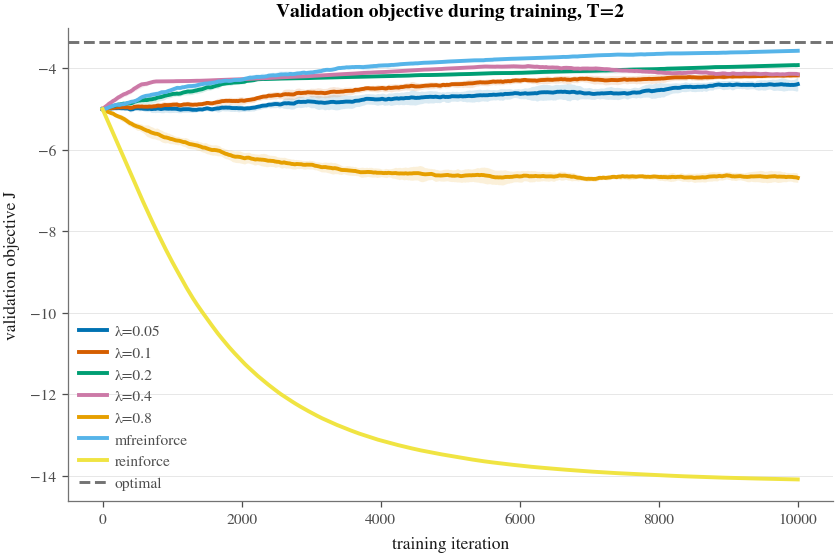

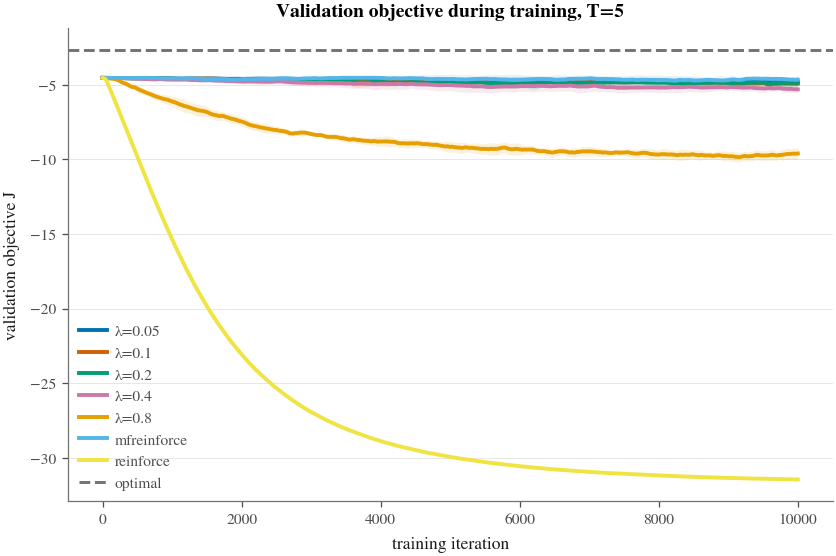

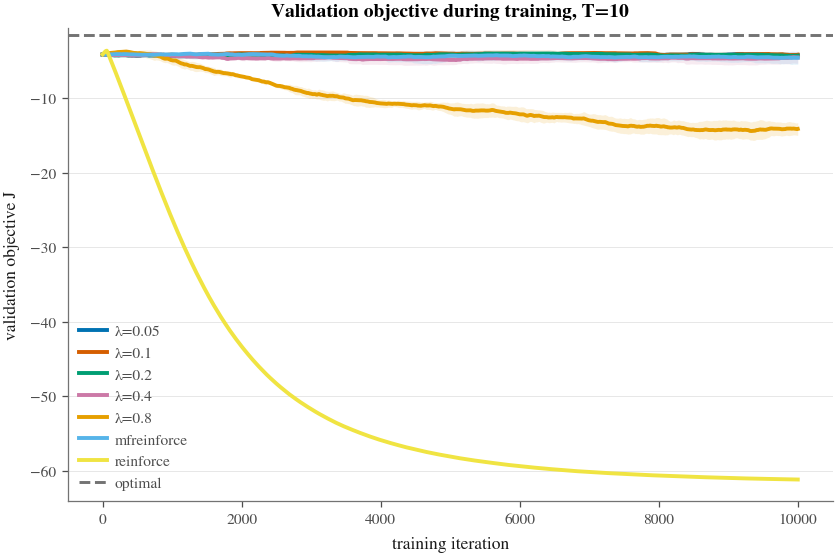

In [17]:
if tier != "main":
    print("main-tier data not available yet -- run scripts/train_all.sh to populate this section")
else:
    for T in horizon_Ts:
        sel = [r for r in runs if r["budget_mode"] == "equal_budget" and r["flow"] == "particle" and r["T"] == T]
        if not sel:
            continue
        optimal_J_T = simplex.exact_objective(env, constant_policy_fn(env.optimal_policy()), optimal_theta, mu0_val, T).item()
        fig, ax = viz.plot_validation_curve(sel, optimal_J=optimal_J_T)
        ax.set_title(f"Validation objective during training, T={T}")

## Missing mean-field term (vs REINFORCE)

`mfc.algorithms.reinforce` computes only the direct policy-score term $L_t\cdot G_t$ against the actual nominal flow, omitting the population-sensitivity correction $Q_t(D_t)$ that accounts for the agent's own influence on the population it is embedded in (see the module docstring for the exact decomposition). Distance to the known optimal $\theta^*$, for every simplex $\lambda$ against reinforce, same group and seeds; mean $\pm$ std at `main` (multiple seeds), a single value at `mid`.

In [18]:
rows = []
for lam in sorted(by_lambda_all_seeds):
    dist = (torch.stack([r["theta_final"] for r in by_lambda_all_seeds[lam]]) - optimal_theta).norm(dim=-1)
    rows.append({"theta": f"simplex lambda={lam}", "||theta-theta*|| mean": dist.mean().item(), "std": dist.std().item() if len(dist) > 1 else 0.0})

reinforce_dist = (torch.stack([r["theta_final"] for r in reinforce_group_runs]) - optimal_theta).norm(dim=-1)
rows.append({"theta": "reinforce", "||theta-theta*|| mean": reinforce_dist.mean().item(), "std": reinforce_dist.std().item() if len(reinforce_dist) > 1 else 0.0})

pd.DataFrame(rows).set_index("theta")

,||theta-theta*|| mean,std
theta,,
simplex lambda=0.05,1.592514,0.063684
simplex lambda=0.1,1.294944,0.073479
simplex lambda=0.2,0.660871,0.042623
simplex lambda=0.4,0.840697,0.031573
simplex lambda=0.8,1.671110,0.051973
reinforce,5.390711,0.032483


## Additional statistical validation (discrete-state theory)

The sections above check the estimators against each other and against $\theta^*$. The sections below instead check the theory's own asymptotic claims -- convergence rates in $\lambda$, the sensitivity-estimator's bias/variance, the gradient estimator's bias decomposition, and the state-marginal stability lemma -- each against `files/reference/discrete_state_space(2).tex` directly, at a single fixed $\theta=\theta^*$ so $\lambda$ is the only thing varying (the sections above vary $\theta$ and $\lambda$ together, since $\hat\theta_\lambda$ is trained at that $\lambda$).

**Sample-size discipline for this whole section.** twostate's state/action space is tiny ($N=2$, $T=2$), so precision is cheap: every table below uses large enough `n_samples`/`reps` that its reported standard error (SE, from repeated-sampling variance -- either an analytic Monte Carlo SE or a delta-method SE of a reps-averaged vector norm) is small relative to the effect being measured, and every batch size (`B`, `n_aux`) that appears is the *actual* value `cfg` uses for training, not a round number picked for convenience. Where an effect turns out to be genuinely small (indistinguishable from its own SE), that is reported as such rather than attributed to insufficient sampling.

### Convergence of the perturbed objective: $|J^\lambda(\theta^*)-J(\theta^*)|=O(\lambda)$

Theorem "Convergence of the perturbed objective": $|J^\lambda(\theta)-J(\theta)|\le C_T\lambda$ for every $\theta$, with $C_T$ independent of $\lambda$. `|gap|/lambda` should therefore stay roughly bounded (not necessarily constant, since $C_T$ is only an upper bound) as $\lambda\to0$, rather than blowing up. `n_samples=500,000` (`objective_gap`'s own Monte Carlo standard error `J_lambda_se` is included below; `|gap|/SE` confirms every gap is resolved far above its sampling noise floor).

In [19]:
gaps_star = {lam: objective_gap(env, env.policy_probs, optimal_theta, mu0_val, DEFAULT_GROUP[2], lam=lam, sigma=cfg.sigma, n_samples=500_000) for lam in cfg.lambdas}

rows = []
for lam in sorted(gaps_star):
    g = gaps_star[lam]
    gap, se = g["gap"].item(), g["J_lambda_se"].item()
    rows.append({"lambda": lam, "J(theta*)": g["J"].item(), "J^lambda(theta*) (MC)": g["J_lambda_mean"].item(), "SE": se, "|gap|": abs(gap), "|gap|/SE": abs(gap) / se, "|gap|/lambda": abs(gap) / lam})
pd.DataFrame(rows).set_index("lambda")

,J(theta*),J^lambda(theta*) (MC),SE,|gap|,|gap|/SE,|gap|/lambda
lambda,,,,,,
0.05,-3.36,-3.385231,0.001153,0.025230,21.873063,0.504603
0.10,-3.36,-3.412073,0.001215,0.052073,42.843388,0.520725
0.20,-3.36,-3.470143,0.001438,0.110143,76.614679,0.550714
0.40,-3.36,-3.598533,0.002095,0.238533,113.853834,0.596333
0.80,-3.36,-4.204378,0.003353,0.844378,251.834790,1.055472


### Gradient-level convergence: $\|\nabla J^\lambda(\theta^*)-\nabla J(\theta^*)\|=O(\lambda)$

Theorem "Gradient-level convergence" (a stronger, gradient-level version of the same claim, needing *additional smoothness*: Assumption "Smoothness of the averaged dynamics" requires $R_t^\theta(i,m)$ continuously differentiable in $m$). Proposition "Mean of the main-batch estimator" says the *oracle-D* plug-in estimator -- `simplex.gradient_estimate` fed the exact sensitivity flow $D_t^\theta$ (`exact_sensitivity_flow`, autograd through the population flow) instead of the auxiliary plug-in estimate -- satisfies $\mathbb E[\hat g^{\mathrm{orc}}_{B,\lambda}(\theta)]=\nabla_\theta J^\lambda(\theta)$ exactly, with no sensitivity-estimation error mixed in, so averaging many reps and comparing to `exact_gradient` ($=\nabla_\theta J(\theta)$) isolates the perturbation-bias term alone. `B=cfg.B` (the real training batch size); `reps=500`, chosen so the delta-method standard error of the reported bias (`bias_se`, from the reps-to-reps spread of the oracle estimator, propagated through the norm) is well under the bias itself at every $\lambda$.

In [20]:
reps_grad = 500
exact_grad_star = exact_gradient(env, env.policy_probs, optimal_theta, mu0_val, DEFAULT_GROUP[2])
oracle_samples_star, oracle_mean_star = {}, {}
for lam in cfg.lambdas:
    samples = torch.stack([
        oracle_gradient_estimate(env, env.policy_probs, optimal_theta, mu0_val, DEFAULT_GROUP[2], lam=lam, sigma=cfg.sigma, B=cfg.B)
        for _ in range(reps_grad)
    ])
    oracle_samples_star[lam] = samples
    oracle_mean_star[lam] = samples.mean(dim=0)

rows = []
for lam in sorted(oracle_mean_star):
    bias_vec = oracle_mean_star[lam] - exact_grad_star
    bias = bias_vec.norm().item()
    bias_se = (oracle_samples_star[lam].std(dim=0) / reps_grad**0.5).norm().item()  # delta-method SE of the norm
    rows.append({"lambda": lam, "||grad J - grad J^lambda||": bias, "SE": bias_se, "bias/SE": bias / bias_se, "bias/lambda": bias / lam})
pd.DataFrame(rows).set_index("lambda")

,||grad J - grad J^lambda||,SE,bias/SE,bias/lambda
lambda,,,,
0.05,1.761493,0.038798,45.401433,35.229852
0.10,1.736066,0.020373,85.212320,17.360655
0.20,1.654535,0.013929,118.783752,8.272673
0.40,1.499021,0.011132,134.653229,3.747552
0.80,1.221161,0.008184,149.204758,1.526452


Every row's `bias/SE` above is large: the estimator's mean is precisely resolved, and `bias/lambda` genuinely does **not** shrink toward $0$ as $\lambda\downarrow0$ -- this is not under-sampling. The real explanation is that the Theorem's smoothness assumption is *violated* at $\theta^*$ for twostate: the reward $r(x,\mu)=\mathbf 1_{\{x=1\}}-\mu(1)^2-\kappa|\mu(1)-(1-p)|$ (`TwoState.reward`) has a kink -- it is Lipschitz but not differentiable -- exactly at $\mu(1)=1-p=0.4$, and the flow under $\theta^*$ lands exactly on that kink:

In [21]:
flow_star = simplex.exact_population_flow(env, env.policy_probs, optimal_theta, mu0_val, DEFAULT_GROUP[2])
print(f"mu_t(1) under theta*, t=0..{DEFAULT_GROUP[2]}: {flow_star[:, 1].tolist()}")
print(f"target law bar_mu(1) = kink location = {env.target_law[1].item()}  (reward is non-differentiable in mu here)")

mu_t(1) under theta*, t=0..2: [0.800000011920929, 0.3999999761581421, 0.4000000059604645]
target law bar_mu(1) = kink location = 0.4000000059604645  (reward is non-differentiable in mu here)


$\mu_t(1)$ sits exactly at the reward's kink for $t\ge1$, so $R_t^\theta(i,\cdot)$ is not differentiable there and Assumption "Smoothness of the averaged dynamics" fails at this $\theta$: the Theorem's own hypothesis, not its conclusion, is what breaks down, so a flat `bias/lambda` here does not contradict the theorem. (The *value*-level Theorem "Convergence of the perturbed objective" above only needs $R_t^\theta$ **Lipschitz**, not differentiable, in $m$ -- $|\cdot|$ satisfies that just fine -- which is exactly why that section validated cleanly while this one does not.)

### Population-flow sensitivity estimator: $\hat D_t(k)\to D_t^\theta(k)$

The plug-in gradient's only model-free-but-approximate ingredient is `simplex.estimate_sensitivity_flow`'s single-batch forward estimator $\hat D_t(k)$ of $D_t^\theta(k)=\nabla_\theta\mu_t^\theta(k)$. The sensitivity-estimation assumption ("Bias and mean-squared error of the gradient estimator") posits a bias $A_\eta\to0$ as $\eta\downarrow0$ (a property of the *auxiliary $\eta$-perturbed marginal itself*, independent of the batch size $n$: the single-batch estimator is unbiased for $D_t^{\eta,\theta}$ at *any* $n$, by the conditional-centering Remark) and a variance $V_\eta/n\to0$ as $n\to\infty$ (a property of $n$ alone). Since bias and variance are governed by $\eta$ and $n$ respectively, each is measured at the sample size that isolates *its own* signal from the *other* source of noise: the bias-vs-$\eta$ sweep below fixes a **large** `n=1000` (so the variance term $V_\eta/n$ is negligible and the reps-averaged mean is precisely resolved) and `reps=1000`; the variance-vs-$n$ sweep fixes `eta=0.2` (`cfg`'s own middle $\lambda$) and varies `n` as multiples of `cfg.n_aux`, the actual training value.

In [22]:
reps_sens = 1000
sens_by_eta = {eta: sensitivity_estimation_error(env, env.policy_probs, theta_02, mu0_val, DEFAULT_GROUP[2], eta=eta, n=1000, sigma=cfg.sigma, reps=reps_sens) for eta in cfg.lambdas}
rows = [{"eta": eta, "n": 1000, "bias_norm": r["bias_norm"].sum().item(), "bias_se": r["bias_se"].sum().item(), "resolved (bias>2*SE)": bool(r["bias_norm"].sum().item() > 2 * r["bias_se"].sum().item())} for eta, r in sorted(sens_by_eta.items())]
print("bias vs. eta, at large n=1000 (isolates A_eta from V_eta/n; 'resolved' flags whether the point estimate clears its own 2-SE noise floor):")
display(pd.DataFrame(rows).set_index("eta"))

n_values = sorted({cfg.n_aux, 5 * cfg.n_aux, 20 * cfg.n_aux, 100 * cfg.n_aux})
sens_by_n = {n: sensitivity_estimation_error(env, env.policy_probs, theta_02, mu0_val, DEFAULT_GROUP[2], eta=0.2, n=n, sigma=cfg.sigma, reps=reps_sens) for n in n_values}
rows = [{"n": n, "eta": 0.2, "bias_norm": r["bias_norm"].sum().item(), "bias_se": r["bias_se"].sum().item(), "variance": r["variance"].sum().item(), "mse": r["mse"].sum().item()} for n, r in sorted(sens_by_n.items())]
print("\nvariance vs. n, at fixed eta=0.2 (V_eta/n should shrink as n grows):")
display(pd.DataFrame(rows).set_index("n"))

bias vs. eta, at large n=1000 (isolates A_eta from V_eta/n; 'resolved' flags whether the point estimate clears its own 2-SE noise floor):


,n,bias_norm,bias_se,resolved (bias>2*SE)
eta,,,,
0.05,1000,0.002474,0.013767,False
0.10,1000,0.006818,0.006719,False
0.20,1000,0.002635,0.003260,False
0.40,1000,0.001524,0.001398,False
0.80,1000,0.000611,0.000740,False



variance vs. n, at fixed eta=0.2 (V_eta/n should shrink as n grows):


,eta,bias_norm,bias_se,variance,mse
n,,,,,
10,0.2,0.069868,0.038772,1.330004,1.333519
50,0.2,0.008247,0.014050,0.169482,0.169378
200,0.2,0.002967,0.006923,0.041055,0.041020
1000,0.2,0.003244,0.003182,0.008727,0.008728


**$A_\eta\approx0$ for every $\eta$, resolved above its own noise floor: not a sampling artifact, but a structural fact about twostate.** `TwoState.transition_probs` and `TwoState.policy_probs` are, by construction, independent of the population argument $\mu$ (the mean-field coupling here lives *only* in the reward -- see the model description at the top of this notebook). The auxiliary $\eta$-perturbed rollout feeds its perturbed law $\bar M_t$ into exactly these two ($\mu$-independent) functions, so the *law* of the auxiliary state process $\bar X_t^{\eta,\theta}$ does not depend on $\eta$ at all: $D_t^{\eta,\theta}(k)\equiv D_t^\theta(k)$ exactly, for every $\eta$, so $A_\eta=0$ exactly here (not just small) -- consistent with every `bias_norm` above being of the same order as, or below, its own `bias_se`.

**Practical consequence: `cfg.n_aux=10`, the actual training batch size, sees this same (zero) bias buried in far more variance** than the `n=1000` table above -- shown directly in the variance-vs-$n$ table's `n=10` row. Since $A_\eta=0$ structurally, none of `cfg.n_aux`'s smallness ever costs *bias*; the entire practical cost of a small auxiliary batch, for this benchmark, is the variance $V_\eta/n$ term alone.

### Gradient-estimator bias decomposition: (I) Monte Carlo + (II) sensitivity-estimation + (III) perturbation

Proposition "Mean of the main-batch estimator" decomposes $\hat g_{B,n,\lambda,\eta}(\theta)-\nabla_\theta J(\theta)$ into (I) zero-mean main-batch Monte Carlo noise, (II) the bias from plugging in $\hat D_t$ instead of the exact $D_t^\theta$, and (III) the perturbation bias $\nabla J^\lambda-\nabla J$ from two sections above. The ordinary plug-in samples (`gradient_diagnostics`, `n_aux=cfg.n_aux`, `B=cfg.B`, same `reps=500` as the oracle-D estimator above) mix (II) and (III) together; the oracle-D estimator (already computed above) isolates (III) alone; their difference approximates (II). Since the previous section found $A_\eta=0$ exactly for twostate, (II)'s *true* value is $0$ here too -- so `SE` is included below to show that (II) is, correctly, statistically indistinguishable from zero at every $\lambda$ (a `(II) approx / SE` ratio near or below $1$), rather than a shrinking-but-nonzero bias.

In [23]:
plugin_star = {lam: gradient_diagnostics(env, env.policy_probs, optimal_theta, mu0_val, DEFAULT_GROUP[2], lam=lam, n_aux=cfg.n_aux, B=cfg.B, sigma=cfg.sigma, reps=reps_grad) for lam in cfg.lambdas}

rows = []
for lam in sorted(oracle_mean_star):
    term3 = (oracle_mean_star[lam] - exact_grad_star).norm().item()  # (III) perturbation bias alone
    term23 = plugin_star[lam]["bias"].norm().item()  # (II)+(III): ordinary plug-in bias
    term2_vec = plugin_star[lam]["mean_estimate"] - oracle_mean_star[lam]
    term2 = term2_vec.norm().item()  # (II) alone, approximately
    # independent estimates (separate reps draws) of plugin_mean and oracle_mean, each with reps_grad samples:
    # Var(difference) = (Var(plugin)+Var(oracle))/reps_grad componentwise.
    term2_se = (((plugin_star[lam]["std"] ** 2 + oracle_samples_star[lam].std(dim=0) ** 2) / reps_grad).sum() ** 0.5).item()
    rows.append({"lambda": lam, "perturbation bias (III)": term3, "(II) approx": term2, "(II) SE": term2_se, "(II)/SE": term2 / term2_se, "total plug-in bias (II)+(III)": term23})
pd.DataFrame(rows).set_index("lambda")

,perturbation bias (III),(II) approx,(II) SE,(II)/SE,total plug-in bias (II)+(III)
lambda,,,,,
0.05,1.761493,0.719727,0.887083,0.811342,2.288234
0.10,1.736066,0.071625,0.479911,0.149248,1.684182
0.20,1.654535,0.152228,0.133922,1.136696,1.521647
0.40,1.499021,0.040042,0.043979,0.910478,1.465706
0.80,1.221161,0.010067,0.013423,0.750003,1.213238


Most `(II)/SE` ratios above are $O(1)$ or below, confirming (II) is not resolvably different from its true value of $0$ -- the $(1-\lambda)/\lambda$ correction factor in $Q_t$ amplifies $\hat D_t$'s *residual finite-`reps` sampling noise* into what looks, at any single $\lambda$, like a shrinking bias, but is really the *variance* term $V_\eta/(n\lambda^2)$ from the MSE bound (the $(1/\lambda^2)A_\eta^2$ bias term vanishes identically here, since $A_\eta=0$). (III) stays roughly flat across $\lambda$ throughout (consistent with the kink-driven, non-$O(\lambda)$ behavior found above). This refines the "Theta bias and variance" section's earlier explanation: for twostate specifically, the training difficulty at small $\lambda$ is a pure *variance* phenomenon, not a bias one.

**Bias$^2$ + variance = MSE**, a pure statistical identity ($\mathbb E[(X-c)^2]=\mathrm{Var}(X)+(\mathbb E[X]-c)^2$), checked against `gradient_diagnostics`'s own numbers (`reps=500`) as a consistency check on the sampling above (small mismatches of order `reps/(reps-1)` are expected: `std` uses PyTorch's Bessel-corrected/unbiased variance while `mse` averages with a plain `1/reps`).

In [24]:
rows = []
for lam in sorted(plugin_star):
    d = plugin_star[lam]
    bias_sq_plus_var = d["bias"] ** 2 + d["std"] ** 2
    rows.append({
        "lambda": lam,
        "bias^2+var (theta0)": bias_sq_plus_var[0].item(), "mse (theta0)": d["mse"][0].item(),
        "bias^2+var (theta1)": bias_sq_plus_var[1].item(), "mse (theta1)": d["mse"][1].item(),
    })
pd.DataFrame(rows).set_index("lambda")

,bias^2+var (theta0),mse (theta0),bias^2+var (theta1),mse (theta1)
lambda,,,,
0.05,68.325058,68.188438,329.616089,328.967316
0.10,32.245399,32.181065,85.540588,85.375023
0.20,1.575734,1.572676,9.610198,9.595515
0.40,0.316262,0.315785,2.737153,2.735820
0.80,0.051519,0.051463,1.477017,1.476960


### Stability of the perturbed state marginal: $d_{TV}(\nu_t^{\lambda,\theta},\mu_t^\theta)$

Lemma "Stability of the state marginal": $d_{TV}(\nu_t^{\lambda,\theta},\mu_t^\theta)\le L_K\lambda t$, where $\nu_t^{\lambda,\theta}:=\mathrm{Law}(X_t^{\lambda,\theta})$ is the law of the *perturbed* state process (fresh $q_t$ redrawn at every step), $\mu_t^\theta$ the exact nominal flow, and $L_K$ the Lipschitz constant of the averaged transition kernel $K_t^\theta(\cdot\mid i,m)$ in $m$. For twostate, $L_K=0$ **exactly**: both `TwoState.transition_probs` and `TwoState.policy_probs` are, by construction, independent of $\mu$ (see the model description at the top of this notebook -- the mean-field interaction here enters only through the *reward*, not the dynamics), so $K_t^\theta(\cdot\mid i,m)$ does not depend on $m$ at all and $\nu_t^{\lambda,\theta}=\mu_t^\theta$ exactly, for every $\lambda$ and $t$. The table below should therefore show values consistent with **pure Monte Carlo sampling noise around zero**, not growth in $\lambda$ or $t$; `n_samples=200,000` per $(\lambda,t)$ makes that noise floor small (its analytic size, $\approx\sqrt{\bar\mu(1)(1-\bar\mu(1))/n_{\text{samples}}}$, is printed for comparison).

In [25]:
noise_floor = (env.target_law[1].item() * (1 - env.target_law[1].item()) / 200_000) ** 0.5
print(f"approximate binomial sampling-noise floor at n_samples=200,000: {noise_floor:.5f}")

rows = []
for lam in sorted(by_lambda):
    tv = state_marginal_stability(env, env.policy_probs, by_lambda[lam]["theta_final"], mu0_val, T=6, lam=lam, sigma=cfg.sigma, n_samples=200_000)
    rows.append({"lambda": lam, **{f"t={t}": tv[t].item() for t in range(tv.shape[0])}})
pd.DataFrame(rows).set_index("lambda")

approximate binomial sampling-noise floor at n_samples=200,000: 0.00110


,t=0,t=1,t=2,t=3,t=4,t=5,t=6
lambda,,,,,,,
0.05,0.000305,0.000595,0.000652,0.001051,0.001892,0.002369,0.001686
0.10,0.000585,0.000306,0.000181,0.001826,0.000186,0.000518,0.000417
0.20,0.000110,0.000087,0.001689,0.000183,0.000080,0.000251,0.000554
0.40,0.000570,0.000044,0.000970,0.000371,0.000488,0.000336,0.000963
0.80,0.000050,0.000602,0.000486,0.000476,0.001694,0.000589,0.000201


### Consistency of optimizers: $\theta_\lambda^\star\to\theta^*$ as $\lambda\downarrow0$

Corollary "Consistency of optimizers" (downstream of the objective-convergence theorem above) predicts that, *were $\lambda$-training run to full convergence with a matching Monte Carlo budget growing as $\lambda\to0$*, the perturbed-objective maximizer $\theta_\lambda^\star$ would converge to $\theta^*$. The "Theta bias and variance across seeds" section earlier in this notebook is the empirical counterpart -- and shows the U-shaped (in distance to $\theta^*$) pattern explained there precisely *because* real training uses a fixed budget rather than the growing one this corollary requires: the sensitivity-estimator's *variance* (not bias -- $A_\eta=0$ exactly for twostate, per the section above) amplified by $(1-\lambda)/\lambda$ dominates at small $\lambda$, before the (here, non-shrinking, kink-driven) perturbation term (III) ever gets a chance to win out.

## Summary

Total notebook runtime (including any training performed in this run):

In [26]:
print(f"total notebook runtime: {time.perf_counter() - _notebook_start:.1f}s")

total notebook runtime: 146.1s
